# Chapter 6: Hiring Screening

Recruiting teams face a familiar bottleneck: a role opens, applications arrive faster than anyone can read them, and the risk of a bad screen in either direction is real. Miss a strong candidate and they accept another offer. Advance a poor fit and you waste an interviewer's time and the candidate's.

Rules-based screening -- keyword matching on required skills, minimum years of experience, degree requirements -- is fast but crude. It filters on the presence of words rather than the quality of fit. A candidate who writes "built distributed systems" passes; one who writes "designed and shipped a high-throughput event pipeline" might not, even if the latter is the stronger hire.

This chapter uses Jev to make a three-option screening decision for each candidate: advance them to interview, flag them for human review, or decline. One `Choice` call per candidate, structured CV summary against structured job requirements, a calibrated confidence score that tells you how certain the decision is.

## Important disclaimer

This chapter is illustrative only. Jev is assessing structured summaries against structured requirements -- it is not making final hiring decisions and should not be used as one. Any real implementation of AI-assisted hiring screening requires human oversight, regular bias auditing and compliance with applicable employment law. The candidates and job description in this chapter are entirely fictional.

## Prerequisites

```shell
export TYPESAFE_API_KEY="your-typesafe-key"
```

## 1. Install dependencies

In [1]:
%pip install pandas==2.2.3 \
             plotly==6.1.2 \
             typesafe-sdk==0.7.2 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and configuration

In [2]:
import os
import pandas as pd
import plotly.graph_objects as go
import time

from typesafe_sdk import Choice, TypeSafeClient

In [3]:
TYPESAFE_API_KEY = os.environ["TYPESAFE_API_KEY"]
print("Configuration set.")

Configuration set.


## 3. Screening options

Three options, matching the natural structure of a screening decision.

In [4]:
SCREENING_DECISION = {
    "Advance": (
        "Candidate meets or exceeds the core requirements for this role. "
        "Invite to first-round interview."
    ),
    "Review": (
        "Candidate partially meets requirements or has an unusual profile "
        "that warrants closer human assessment before a decision is made."
    ),
    "Decline": (
        "Candidate does not meet the core requirements for this role at "
        "this time."
    ),
}

print("Options:", list(SCREENING_DECISION.keys()))

Options: ['Advance', 'Review', 'Decline']


## 4. The role

A single job description used for all 20 candidates.

In [5]:
JOB = {
    "title": "Senior Backend Engineer",
    "team": "Platform Engineering",
    "level": "Senior (5+ years relevant experience)",
    "required_skills": [
        "Python or Go (primary language)",
        "Distributed systems design",
        "REST and/or gRPC API design",
        "SQL and NoSQL databases",
        "Cloud infrastructure (AWS, GCP or Azure)",
    ],
    "preferred_skills": [
        "Kafka or similar message queue experience",
        "Kubernetes and container orchestration",
        "Experience with high-throughput or real-time systems",
    ],
    "responsibilities": [
        "Design and build scalable backend services",
        "Own technical architecture decisions for platform components",
        "Mentor junior engineers",
        "Collaborate with product and infrastructure teams",
    ],
    "not_suitable": [
        "Candidates with fewer than 3 years of backend experience",
        "Frontend-only or data science backgrounds without backend exposure",
        "Candidates whose experience is primarily in monolithic architectures "
        "with no distributed systems work",
    ],
}

print(f"Role: {JOB['title']} -- {JOB['team']}")
print(f"Level: {JOB['level']}")
print(f"Required: {', '.join(JOB['required_skills'])}")

Role: Senior Backend Engineer -- Platform Engineering
Level: Senior (5+ years relevant experience)
Required: Python or Go (primary language), Distributed systems design, REST and/or gRPC API design, SQL and NoSQL databases, Cloud infrastructure (AWS, GCP or Azure)


## 5. Generate synthetic candidates

Twenty candidates across four bands. Each has a structured CV summary covering experience, skills, recent roles and any notable signals.

In [6]:
CANDIDATES = [

    # Strong match (5)
    {
        "id": "C001",
        "name": "Alex Rivera",
        "years_experience": 7,
        "current_title": "Senior Software Engineer",
        "summary": (
            "7 years building backend services in Python and Go. Currently at a fintech scale-up designing distributed payment processing systems handling 1M+ transactions per day. Deep experience with Kafka, PostgreSQL and Redis. Extensive AWS usage. Has mentored a team of 4 junior engineers. Led the migration of a monolithic payments service to microservices."
        ),
        "band": "strong_match",
    },
    {
        "id": "C002",
        "name": "Jordan Kim",
        "years_experience": 8,
        "current_title": "Staff Engineer",
        "summary": (
            "8 years in backend engineering, primarily Go. Staff Engineer at a logistics platform, owning the real-time tracking infrastructure for 500k daily active users. Designed and built gRPC APIs consumed by 6 internal teams. Kubernetes and GCP native. Experienced technical mentor and architecture reviewer."
        ),
        "band": "strong_match",
    },
    {
        "id": "C003",
        "name": "Sam Okonkwo",
        "years_experience": 6,
        "current_title": "Backend Engineer",
        "summary": (
            "6 years backend engineering in Python. Currently building data pipeline infrastructure at a healthcare SaaS company: REST APIs, PostgreSQL, DynamoDB, deployed on Azure. Has led two major API redesigns and is the primary on-call engineer for the core platform. Some Kafka experience from a previous role."
        ),
        "band": "strong_match",
    },
    {
        "id": "C004",
        "name": "Maya Patel",
        "years_experience": 9,
        "current_title": "Principal Engineer",
        "summary": (
            "9 years in backend engineering. Principal Engineer at an e-commerce platform, responsible for the order management and inventory systems serving 50M users. Python and Go. Event-driven architecture using Kafka. PostgreSQL at scale. AWS certified solutions architect. Mentors senior engineers."
        ),
        "band": "strong_match",
    },
    {
        "id": "C005",
        "name": "Chris Nakamura",
        "years_experience": 5,
        "current_title": "Senior Backend Engineer",
        "summary": (
            "5 years backend engineering, exactly at the seniority threshold. Python primary language. Builds REST APIs and background job systems at a B2B SaaS startup. SQL (PostgreSQL, MySQL) and some MongoDB. AWS. Has designed and shipped two major platform features independently. No Kafka experience but strong distributed systems fundamentals."
        ),
        "band": "strong_match",
    },

    # Clear mismatch (5)
    {
        "id": "C006",
        "name": "Taylor Brooks",
        "years_experience": 2,
        "current_title": "Junior Frontend Developer",
        "summary": (
            "2 years as a frontend developer. React and TypeScript specialist. Has built several user interfaces for internal tools. No backend experience. Some familiarity with REST APIs from the consumer side. Looking to transition to full-stack in the future."
        ),
        "band": "clear_mismatch",
    },
    {
        "id": "C007",
        "name": "Morgan Ellis",
        "years_experience": 4,
        "current_title": "Data Scientist",
        "summary": (
            "4 years as a data scientist. Python for ML pipelines, pandas, scikit-learn, PyTorch. Has built batch data processing scripts and Jupyter notebooks. No production backend or API design experience. Strong quantitative background but no distributed systems work."
        ),
        "band": "clear_mismatch",
    },
    {
        "id": "C008",
        "name": "Jamie Foster",
        "years_experience": 1,
        "current_title": "Graduate Software Engineer",
        "summary": (
            "1 year post-graduation. Computer science degree. Has worked on a monolithic Django application handling internal HR processes. Solid fundamentals but limited production experience. No distributed systems, no cloud infrastructure ownership."
        ),
        "band": "clear_mismatch",
    },
    {
        "id": "C009",
        "name": "Riley Chen",
        "years_experience": 6,
        "current_title": "iOS Engineer",
        "summary": (
            "6 years building iOS applications in Swift and Objective-C. Senior iOS engineer at a consumer app. Has consumed REST APIs extensively but has not designed or built backend services. No cloud infrastructure experience. No distributed systems background."
        ),
        "band": "clear_mismatch",
    },
    {
        "id": "C010",
        "name": "Casey Wong",
        "years_experience": 3,
        "current_title": "QA Engineer",
        "summary": (
            "3 years in quality assurance. Writes automated test suites in Python. Deep understanding of API contracts from a testing perspective but has not built production services. No backend architecture experience. Interested in transitioning to engineering roles."
        ),
        "band": "clear_mismatch",
    },

    # Borderline (5)
    {
        "id": "C011",
        "name": "Dana Osei",
        "years_experience": 3,
        "current_title": "Backend Engineer",
        "summary": (
            "3 years backend engineering in Python. Has built REST APIs and background workers at a mid-size startup. PostgreSQL. Some AWS experience. Good fundamentals but below the preferred seniority level. No distributed systems experience yet. Shows strong growth trajectory."
        ),
        "band": "borderline",
    },
    {
        "id": "C012",
        "name": "Avery Santos",
        "years_experience": 7,
        "current_title": "Senior Java Engineer",
        "summary": (
            "7 years backend engineering but primarily in Java and Spring Boot. Has worked on distributed systems and REST APIs at enterprise scale. Strong architecture and systems design skills. No Python or Go experience. Would need to ramp up on the preferred stack."
        ),
        "band": "borderline",
    },
    {
        "id": "C013",
        "name": "Quinn Murphy",
        "years_experience": 5,
        "current_title": "DevOps Engineer",
        "summary": (
            "5 years in DevOps and platform engineering. Deep Kubernetes and AWS expertise. Manages the infrastructure that backend engineers build on. Has written deployment scripts and automation in Python but has not built production application services or APIs. Understands distributed systems from an operational rather than development perspective."
        ),
        "band": "borderline",
    },
    {
        "id": "C014",
        "name": "Skyler Park",
        "years_experience": 6,
        "current_title": "Full Stack Engineer",
        "summary": (
            "6 years full stack. Backend in Node.js and some Python. Has built REST APIs and integrations. SQL databases. Deployed on AWS. About half their experience is frontend work. Backend experience is solid but not as deep as a purely backend-focused candidate at this level."
        ),
        "band": "borderline",
    },
    {
        "id": "C015",
        "name": "Drew Hassan",
        "years_experience": 5,
        "current_title": "Backend Engineer",
        "summary": (
            "5 years backend engineering. Python. Has built microservices and REST APIs. SQL databases. The majority of their experience is at a single early-stage startup where they were the sole backend engineer, so depth of team collaboration and large-scale systems experience is unclear. Strong ownership signals but limited peer review or mentoring context."
        ),
        "band": "borderline",
    },

    # Edge cases (5)
    {
        "id": "C016",
        "name": "Frankie Diaz",
        "years_experience": 12,
        "current_title": "Principal Engineer",
        "summary": (
            "12 years of backend engineering experience. Currently a Principal Engineer overseeing architecture for a 200-person engineering organisation. Deep Python and Go expertise. Has designed distributed systems at very large scale. The role being applied for is below their current seniority level -- they may be seeking a less management-heavy position or a deliberate step back."
        ),
        "band": "edge",
    },
    {
        "id": "C017",
        "name": "Reese Andersen",
        "years_experience": 8,
        "current_title": "Senior Backend Engineer",
        "summary": (
            "8 years backend experience with a 2-year gap in employment history (2022-2024). CV notes the gap was for personal reasons. Before the gap: strong Python and distributed systems background, REST and gRPC APIs, Kafka, AWS. Post-gap: 6 months at a startup before it folded. All core skills present but gap may indicate recency concerns."
        ),
        "band": "edge",
    },
    {
        "id": "C018",
        "name": "Blair Kim",
        "years_experience": 6,
        "current_title": "Backend Engineer",
        "summary": (
            "6 years experience but CV is poorly structured and uses vague language: 'worked on backend systems', 'involved in API development', 'contributed to database design'. Technical skills listed without context. It is unclear whether this reflects limited experience or poor CV writing. Has open-source contributions on GitHub that suggest stronger skills than the CV conveys."
        ),
        "band": "edge",
    },
    {
        "id": "C019",
        "name": "Robin Castillo",
        "years_experience": 7,
        "current_title": "Senior Backend Engineer",
        "summary": (
            "7 years backend engineering, but the most recent 3 years have been entirely in PHP and Laravel at a traditional web agency. Earlier experience includes Python and REST API work. Has not worked with distributed systems, Kafka or modern cloud infrastructure. Strong fundamentals but the recent stack is a significant distance from what this role requires."
        ),
        "band": "edge",
    },
    {
        "id": "C020",
        "name": "Sage Thompson",
        "years_experience": 6,
        "current_title": "Senior Software Engineer",
        "summary": (
            "6 years experience, career changer from mechanical engineering. Self-taught programmer who transitioned 6 years ago. Python primary language. Has built and shipped backend services at two startups: REST APIs, PostgreSQL, AWS. No computer science degree but strong practical background and clear progression. No distributed systems or Kafka experience."
        ),
        "band": "edge",
    },
]

candidates_df = pd.DataFrame(CANDIDATES)
print(f"Generated {len(candidates_df)} candidates")
print()
print(candidates_df[["id", "name", "years_experience", "current_title", "band"]]
      .to_string(index=False))

Generated 20 candidates

  id           name  years_experience              current_title           band
C001    Alex Rivera                 7   Senior Software Engineer   strong_match
C002     Jordan Kim                 8             Staff Engineer   strong_match
C003    Sam Okonkwo                 6           Backend Engineer   strong_match
C004     Maya Patel                 9         Principal Engineer   strong_match
C005 Chris Nakamura                 5    Senior Backend Engineer   strong_match
C006  Taylor Brooks                 2  Junior Frontend Developer clear_mismatch
C007   Morgan Ellis                 4             Data Scientist clear_mismatch
C008   Jamie Foster                 1 Graduate Software Engineer clear_mismatch
C009     Riley Chen                 6               iOS Engineer clear_mismatch
C010     Casey Wong                 3                QA Engineer clear_mismatch
C011      Dana Osei                 3           Backend Engineer     borderline
C012   Avery Sa

## 6. Jev screening

One `Choice` call per candidate. The job requirements go into the state alongside the candidate's structured CV summary.

In [7]:
jev_client = TypeSafeClient(model="jev-1.13.0")
print("Jev client ready.")

Jev client ready.


In [8]:
def screen_candidate(client, candidate, job):
    state = {
        "role_title":          job["title"],
        "seniority_level":     job["level"],
        "required_skills":     job["required_skills"],
        "preferred_skills":    job["preferred_skills"],
        "not_suitable_if":     job["not_suitable"],
        "candidate_summary":   candidate["summary"],
        "years_experience":    candidate["years_experience"],
        "current_title":       candidate["current_title"],
    }

    t0 = time.time()
    response = client.system_one(
        state=state,
        questions={
            "decision": Choice(
                instructions=(
                    "Based on the candidate's experience and the role requirements, "
                    "should this candidate be advanced to interview, flagged for "
                    "human review, or declined? Assess fit on required skills, "
                    "seniority level and relevant experience."
                ),
                criteria=SCREENING_DECISION,
            )
        },
    )
    elapsed = (time.time() - t0) * 1000
    answer  = response.choices["decision"]

    return {
        "id":         candidate["id"],
        "name":       candidate["name"],
        "band":       candidate["band"],
        "title":      candidate["current_title"],
        "years":      candidate["years_experience"],
        "decision":   answer.choice,
        "confidence": round(answer.confidence, 2),
        "elapsed_ms": round(elapsed, 1),
    }

In [9]:
results = []
for candidate in CANDIDATES:
    result = screen_candidate(jev_client, candidate, JOB)
    results.append(result)
    print(f"{result['id']} [{result['band']:15}] "
          f"{result['name']:<18} "
          f"-> {result['decision']:7} ({result['confidence']:.2f})")

results_df = pd.DataFrame(results)

C001 [strong_match   ] Alex Rivera        -> Advance (1.00)
C002 [strong_match   ] Jordan Kim         -> Advance (1.00)
C003 [strong_match   ] Sam Okonkwo        -> Advance (0.99)
C004 [strong_match   ] Maya Patel         -> Advance (1.00)
C005 [strong_match   ] Chris Nakamura     -> Advance (0.87)
C006 [clear_mismatch ] Taylor Brooks      -> Decline (1.00)
C007 [clear_mismatch ] Morgan Ellis       -> Decline (1.00)
C008 [clear_mismatch ] Jamie Foster       -> Decline (1.00)
C009 [clear_mismatch ] Riley Chen         -> Decline (1.00)
C010 [clear_mismatch ] Casey Wong         -> Decline (0.99)
C011 [borderline     ] Dana Osei          -> Decline (0.81)
C012 [borderline     ] Avery Santos       -> Review  (0.51)
C013 [borderline     ] Quinn Murphy       -> Decline (0.70)
C014 [borderline     ] Skyler Park        -> Review  (0.84)
C015 [borderline     ] Drew Hassan        -> Review  (0.94)
C016 [edge           ] Frankie Diaz       -> Review  (0.61)
C017 [edge           ] Reese Andersen   

## 7. Results

In [10]:
results_df[["id", "name", "band", "decision", "confidence"]]

,id,name,band,decision,confidence
0,C001,Alex Rivera,strong_match,Advance,1.00
1,C002,Jordan Kim,strong_match,Advance,1.00
2,C003,Sam Okonkwo,strong_match,Advance,0.99
3,C004,Maya Patel,strong_match,Advance,1.00
4,C005,Chris Nakamura,strong_match,Advance,0.87
5,C006,Taylor Brooks,clear_mismatch,Decline,1.00
6,C007,Morgan Ellis,clear_mismatch,Decline,1.00
7,C008,Jamie Foster,clear_mismatch,Decline,1.00
8,C009,Riley Chen,clear_mismatch,Decline,1.00
9,C010,Casey Wong,clear_mismatch,Decline,0.99


## 8. Confidence by band

Strong matches and clear mismatches should produce high confidence. Borderline and edge cases should produce lower confidence, with Review being the natural landing spot for uncertain decisions.

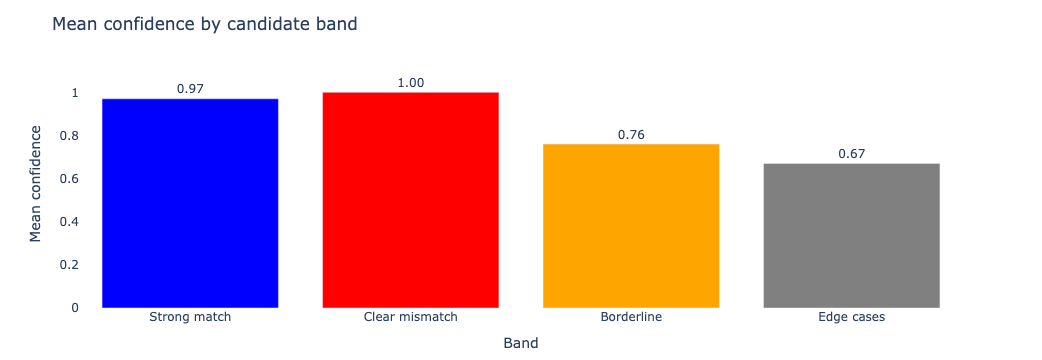


    band_label  mean_confidence  advanced  reviewed  declined
  Strong match             0.97         5         0         0
Clear mismatch             1.00         0         0         5
    Borderline             0.76         0         3         2
    Edge cases             0.67         0         4         1


In [11]:
band_order  = ["strong_match", "clear_mismatch", "borderline", "edge"]
band_labels = {
    "strong_match":   "Strong match",
    "clear_mismatch": "Clear mismatch",
    "borderline":     "Borderline",
    "edge":           "Edge cases",
}

band_summary = (
    results_df
    .groupby("band")
    .agg(
        mean_confidence=("confidence", "mean"),
        count          =("id",         "count"),
        advanced       =("decision",   lambda x: (x == "Advance").sum()),
        reviewed       =("decision",   lambda x: (x == "Review").sum()),
        declined       =("decision",   lambda x: (x == "Decline").sum()),
    )
    .reset_index()
)
band_summary["band"] = pd.Categorical(
    band_summary["band"], categories=band_order, ordered=True
)
band_summary = band_summary.sort_values("band")
band_summary["band_label"] = band_summary["band"].map(band_labels)
band_summary["mean_confidence"] = band_summary["mean_confidence"].round(2)

fig1 = go.Figure(go.Bar(
    x=band_summary["band_label"],
    y=band_summary["mean_confidence"],
    marker_color=["blue", "red", "orange", "grey"],
    text=[f"{v:.2f}" for v in band_summary["mean_confidence"]],
    textposition="outside",
))
fig1.update_layout(
    title="Mean confidence by candidate band",
    xaxis_title="Band",
    yaxis_title="Mean confidence",
    yaxis=dict(range=[0, 1.15]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
)
fig1.show()

print()
print(band_summary[["band_label", "mean_confidence", "advanced", "reviewed", "declined"]]
      .to_string(index=False))

## 9. Decision distribution

Does Jev use Review as a genuine middle ground, or does it collapse to binary advance/decline?

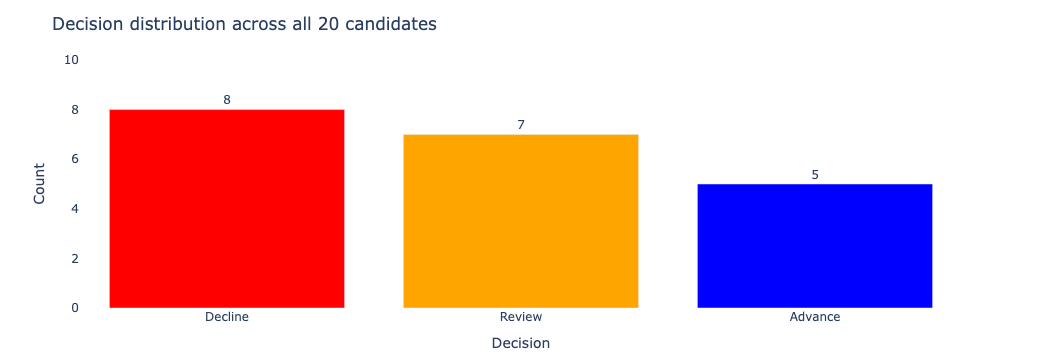


  Decline: 8 candidates, mean confidence 0.89
  Review : 7 candidates, mean confidence 0.72
  Advance: 5 candidates, mean confidence 0.97


In [12]:
decision_counts = results_df["decision"].value_counts().reset_index()
decision_counts.columns = ["decision", "count"]
decision_counts["color"] = decision_counts["decision"].map({
    "Advance": "blue",
    "Review":  "orange",
    "Decline": "red",
})

fig2 = go.Figure(go.Bar(
    x=decision_counts["decision"],
    y=decision_counts["count"],
    marker_color=decision_counts["color"],
    text=decision_counts["count"],
    textposition="outside",
))
fig2.update_layout(
    title="Decision distribution across all 20 candidates",
    xaxis_title="Decision",
    yaxis_title="Count",
    yaxis=dict(range=[0, decision_counts["count"].max() + 2]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
)
fig2.show()

print()
for _, row in decision_counts.iterrows():
    mean_conf = results_df[results_df["decision"] == row["decision"]]["confidence"].mean()
    print(f"  {row['decision']:7}: {row['count']} candidates, "
          f"mean confidence {mean_conf:.2f}")

## 10. Confidence by decision

Each candidate as a point, grouped by decision.

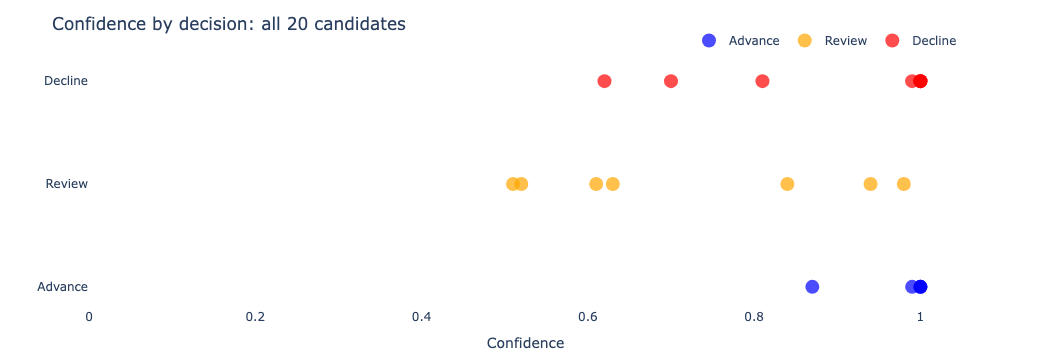

In [13]:
fig3 = go.Figure()

colors = {"Advance": "blue", "Review": "orange", "Decline": "red"}

for decision, color in colors.items():
    subset = results_df[results_df["decision"] == decision]
    if subset.empty:
        continue
    fig3.add_trace(go.Scatter(
        x=subset["confidence"],
        y=subset["decision"],
        mode="markers",
        name=decision,
        marker=dict(color=color, size=14, opacity=0.7),
        text=subset["id"] + " -- " + subset["name"] + "<br>" + subset["band"],
        hoverinfo="text+x",
    ))

fig3.update_layout(
    title="Confidence by decision: all 20 candidates",
    xaxis_title="Confidence",
    xaxis=dict(range=[0, 1.05]),
    yaxis_title="",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig3.show()

## 11. Latency

In [14]:
print(f"Mean: {results_df['elapsed_ms'].mean():.0f}ms")
print(f"Min:  {results_df['elapsed_ms'].min():.0f}ms")
print(f"Max:  {results_df['elapsed_ms'].max():.0f}ms")

Mean: 262ms
Min:  204ms
Max:  406ms


## 12. Summary

One `Choice` call per candidate screened 20 applications against a structured job description. Strong matches and clear mismatches produced high confidence. Borderline and edge cases produced lower confidence, with the Review option capturing the candidates who genuinely need a human look before a decision is made.

The confidence score is the key signal. A high-confidence Advance or Decline can be processed automatically. A low-confidence decision -- regardless of which option Jev chose -- should go to a human reviewer. This is the same pattern we've seen across every chapter: the confidence score is more informative than the decision itself when the situation is genuinely uncertain.

As noted at the start of this chapter, this is illustrative only. Hiring decisions carry real consequences for real people. AI-assisted screening can help with throughput but must always have human oversight, regular bias auditing and clear accountability for final decisions.